In [ ]:
# ============================================================
# CELL 1: IMPORT THƯ VIỆN
# ============================================================
# Chạy cell này đầu tiên. Nếu thiếu thư viện nào Colab báo lỗi
# ngay đây — dễ debug hơn là lỗi giữa chừng khi đang train.

import os, json, pickle, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_recall_curve, recall_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

warnings.filterwarnings('ignore')

# Cố định seed để kết quả reproducible — chạy lại ra kết quả giống nhau
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Kiểm tra GPU — có GPU thì train nhanh hơn ~10x
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow : {tf.__version__} | GPU: {gpus}')

if gpus:
    # Không cấp hết VRAM ngay từ đầu, dùng bao nhiêu cấp bấy nhiêu
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        # Mixed precision fp16: tăng tốc ~2x trên T4/A100, accuracy không đổi
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision: ON')
    except Exception as e:
        print(f'Mixed precision N/A: {e}')
else:
    print('⚠️  Không có GPU — vào Runtime > Change runtime type > T4 GPU')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')
print('✅ Import xong.')

TensorFlow : 2.19.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: ON
✅ Import xong.


In [ ]:
# ============================================================
# CELL 2: CONFIG & ĐƯỜNG DẪN DATA
# ============================================================
# Tất cả tham số quan trọng tập trung ở đây.
# Muốn thay đổi bất cứ thứ gì → sửa ở cell này, KHÔNG sửa rải rác.

# Mount Google Drive để đọc data và lưu model
IN_COLAB = 'google.colab' in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ── Đường dẫn 6 subjects ─────────────────────────────────────
# Cập nhật so với notebook cũ: thêm An, Hao, Quan (trước chỉ có Hieu, Kien, Tien)
DATA_ROOTS = [
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/An'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hao'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Hieu'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Kien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Quan'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Tien'),
    Path('/content/drive/MyDrive/data_pbl5/Self-Collected/Cong'),
]
OUTPUT_DIR = Path('/content/drive/MyDrive/data_pbl5/lstm_loso_cross_hyperparameter_tuning')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Tham số cảm biến & window ────────────────────────────────
SAMPLE_RATE   = 50      # ESP32 thu 50 mẫu/giây
WINDOW_SIZE   = 100     # 100 mẫu = 2 giây/window
OVERLAP_RATIO = 0.5     # Bước nhảy = 50 mẫu = 1 giây
NUM_CHANNELS  = 6       # ax, ay, az, gx, gy, gz
CLASS_NAMES   = ['Normal', 'Fall']
EXCLUDE_SUBFOLDERS = ['LonXon']
# ── Tham số training ─────────────────────────────────────────
TEST_SIZE     = 0.15    # 15% test (chỉ dùng cho lần train 1)
VAL_SIZE      = 0.15    # 15% validation
EPOCHS        = 150     # EarlyStopping sẽ dừng sớm nếu không cải thiện
BATCH_SIZE    = 32      # Nhỏ hơn 64 vì dataset không quá lớn
LEARNING_RATE = 5e-4    # Thấp hơn 1e-3 vì model có Attention nhạy cảm với LR cao
DROPOUT_RATE  = 0.35    # Regularization — tránh overfit trên dataset nhỏ
L2_REG        = 2e-4    # L2 weight decay thêm vào

# ── Tham số quan trọng nhất: số window "nóng" giữ lại từ Fall session ──
#
# VẤN ĐỀ GỐC RỄ khiến model cũ hay báo nhầm:
#   Quy trình thu data: bấm nút → té → nằm yên ~2-3s → tắt session
#   → Sliding window tạo ra nhiều window từ phần "nằm yên sau ngã"
#   → Những window này có magnitude ≈ 9.8 m/s² (trọng lực thuần)
#   → Trông GIỐNG HỆT người đứng/ngồi yên (Normal)
#   → Model học nhầm: "nằm yên = Fall" → false positive khi deploy
#
# GIẢI PHÁP: Chỉ giữ N_HOT_WINDOWS window ĐẦU TIÊN của mỗi Fall session
#   Bước nhảy = 50 mẫu = 1s → 8 windows đầu ≈ 8 giây đầu
#   8 giây đầu chứa: cú freefall + impact + vài giây nằm yên ngay sau ngã
#   Phần còn lại (nằm yên dài) bị loại bỏ
#
# Gợi ý: nếu session Fall của bạn ngắn (~3-4s) thì giảm xuống N_HOT_WINDOWS = 5
#         nếu dài hơn (~10s) thì tăng lên 10-12
N_HOT_WINDOWS = 5

print('✅ Config:')
print(f'  Window     : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLE_RATE:.1f}s @ {SAMPLE_RATE}Hz')
print(f'  Bước nhảy  : {int(WINDOW_SIZE*(1-OVERLAP_RATIO))} samples = {int(WINDOW_SIZE*(1-OVERLAP_RATIO)/SAMPLE_RATE*1000)}ms')
print(f'  Subjects   : {len(DATA_ROOTS)} người')
print(f'  Hot windows: giữ {N_HOT_WINDOWS} window đầu/Fall session (~{N_HOT_WINDOWS}s đầu)')
print(f'  Output dir : {OUTPUT_DIR}')

Mounted at /content/drive
✅ Config:
  Window     : 100 samples = 2.0s @ 50Hz
  Bước nhảy  : 50 samples = 1000ms
  Subjects   : 7 người
  Hot windows: giữ 5 window đầu/Fall session (~5s đầu)
  Output dir : /content/drive/MyDrive/data_pbl5/lstm_loso_cross_hyperparameter_tuning


In [ ]:
# ============================================================
# CELL 3: LOAD DATA
# ============================================================
def load_session(session_dir):
    session_dir = Path(session_dir)
    accel_path  = session_dir / 'accel.csv'
    gyro_path   = session_dir / 'gyro.csv'

    if not (accel_path.exists() and gyro_path.exists()):
        return None, None

    folder_name = session_dir.name
    label = None
    if folder_name.startswith('label'):
        try:
            label = int(folder_name[5])
        except (ValueError, IndexError):
            label = None
    if label is None:
        label_path = session_dir / 'label.txt'
        if label_path.exists():
            try:
                label = int(label_path.read_text().strip())
            except Exception:
                return None, None
        else:
            return None, None

    try:
        accel = pd.read_csv(accel_path)
        gyro  = pd.read_csv(gyro_path)
    except Exception:
        return None, None

    if accel.empty or gyro.empty:
        return None, None
    if accel.shape[1] != 4 or gyro.shape[1] != 4:
        return None, None

    accel.columns = ['time', 'ax', 'ay', 'az']
    gyro.columns  = ['time', 'gx', 'gy', 'gz']

    min_len = min(len(accel), len(gyro))
    df = pd.concat([
        accel[['ax', 'ay', 'az']].iloc[:min_len].reset_index(drop=True),
        gyro [['gx', 'gy', 'gz']].iloc[:min_len].reset_index(drop=True),
    ], axis=1)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)

    if len(df) < WINDOW_SIZE // 2:
        return None, None

    return df, label


def load_all_sessions(data_roots):
    sessions = []
    stats = {name: 0 for name in CLASS_NAMES}
    stats['errors'] = stats['skipped'] = 0

    def find_session_dirs(base_dir):
        result = []
        if not base_dir.exists():
            return result
        for entry in sorted(base_dir.iterdir()):
            if entry.is_dir():
                if (entry / 'accel.csv').exists():
                    result.append(entry)
                else:
                    result.extend(find_session_dirs(entry))
        return result

    for root in data_roots:
        root        = Path(root)
        person_name = root.name
        print(f'\n📁 {root}  [subject={person_name}]')

        for class_name in CLASS_NAMES:
            class_dir = root / class_name
            if not class_dir.exists():
                print(f'   ⚠️  Thiếu thư mục: {class_dir}')
                continue

            sess_dirs = find_session_dirs(class_dir)

            # ── Filter EXCLUDE_SUBFOLDERS ─────────────────────
            before = len(sess_dirs)
            sess_dirs = [
                sd for sd in sess_dirs
                if not any(ex in sd.parts for ex in EXCLUDE_SUBFOLDERS)
            ]
            after = len(sess_dirs)
            if before != after:
                print(f'   🗑️  {class_name}: bỏ {before - after} sessions '
                      f'({EXCLUDE_SUBFOLDERS}) → còn {after}')

            print(f'   {class_name}: {len(sess_dirs)} sessions')

            subfolder_counts = {}
            for sd in sess_dirs:
                try:
                    subfolder = sd.relative_to(class_dir).parts[0]
                except Exception:
                    subfolder = '(root)'
                subfolder_counts[subfolder] = subfolder_counts.get(subfolder, 0) + 1
            for sf, cnt in sorted(subfolder_counts.items()):
                print(f'      └─ {sf}: {cnt}')

            expected_label = CLASS_NAMES.index(class_name)
            for sess_dir in sess_dirs:
                df, lbl = load_session(sess_dir)
                if df is None:
                    stats['errors'] += 1
                    continue
                if lbl != expected_label:
                    print(f'   ⚠️  Label mismatch: {sess_dir.name} '
                          f'(file={lbl}, expected={expected_label})')
                    stats['skipped'] += 1
                    continue
                stats[class_name] += 1
                sessions.append((df, lbl, person_name))

    print('\n' + '─' * 50)
    total = sum(stats[c] for c in CLASS_NAMES)
    print(f'📊 Tổng sessions hợp lệ: {total}')
    for c in CLASS_NAMES:
        print(f'   {c:7}: {stats[c]}')
    print(f'   Lỗi / mismatch: {stats["errors"]} / {stats["skipped"]}')

    if not sessions:
        raise ValueError('❌ Không có session nào.')
    found_labels = {lbl for _, lbl, _ in sessions}
    if len(found_labels) < 2:
        raise ValueError(f'❌ Chỉ có 1 class.')
    return sessions


all_sessions = load_all_sessions(DATA_ROOTS)
print(f'\n✅ Load xong: {len(all_sessions)} sessions.')


📁 /content/drive/MyDrive/data_pbl5/Self-Collected/An  [subject=An]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hao  [subject=Hao]
   Normal: 52 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 17
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 50 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 25

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Hieu  [subject=Hieu]
   Normal: 50 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 15
      └─ GoPhim: 10
      └─ LuotDienThoai: 10
   Fall: 51 sessions
      └─ NgaRaSau: 25
      └─ NgaRaTruoc: 26

📁 /content/drive/MyDrive/data_pbl5/Self-Collected/Kien  [subject=Kien]
   Normal: 45 sessions
      └─ ChayBoCham: 15
      └─ DiBo: 11
      └─ GoPhim: 10
      └─ LuotDienThoai: 9
   Fall: 36 sessions
      └─ NgaRaSau: 18
      └─ NgaRaTruoc: 18

📁 

📊 Phân bố sessions theo subject:
Subject      Normal     Fall    Total
──────────────────────────────────────
An               50       50      100
Cong             52       60      112
Hao              52       50      102
Hieu             50       51      101
Kien             45       36       81
Quan             51       50      101
Tien             52       50      102


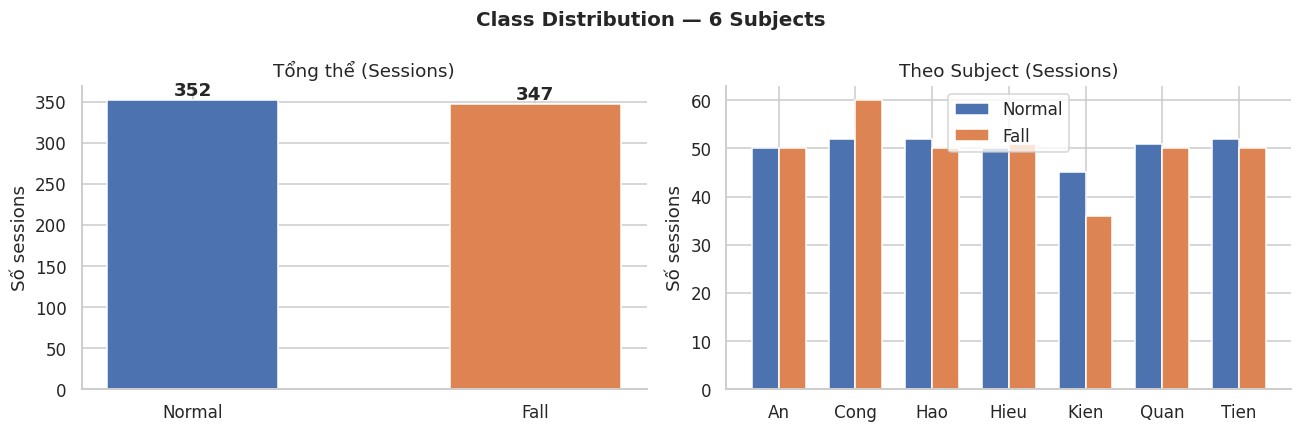


⚠️  Nếu subject nào có số Fall = 0 hoặc Normal = 0
   thì fold LOSO tương ứng sẽ bị bỏ qua tự động.


In [ ]:
# ============================================================
# CELL 4: VISUALIZE PHÂN BỐ DATA
# ============================================================
# Kiểm tra xem mỗi subject có bao nhiêu session Normal / Fall.
# Nếu 1 subject chỉ có Normal hoặc chỉ có Fall → LOSO fold đó sẽ bị bỏ qua.

# Thống kê theo subject
print('📊 Phân bố sessions theo subject:')
print(f'{"Subject":<10} {"Normal":>8} {"Fall":>8} {"Total":>8}')
print('─' * 38)
subject_stats = {}
for _, lbl, person in all_sessions:
    if person not in subject_stats:
        subject_stats[person] = [0, 0]
    subject_stats[person][lbl] += 1
for person, counts in sorted(subject_stats.items()):
    total = sum(counts)
    print(f'{person:<10} {counts[0]:>8} {counts[1]:>8} {total:>8}')

labels_all   = [lbl for _, lbl, _ in all_sessions]
label_counts = {name: labels_all.count(i) for i, name in enumerate(CLASS_NAMES)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — 6 Subjects', fontsize=13, fontweight='bold')

# Biểu đồ tổng thể
bars = axes[0].bar(CLASS_NAMES, [label_counts[n] for n in CLASS_NAMES],
                   color=['#4C72B0', '#DD8452'], edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Tổng thể (Sessions)')
axes[0].set_ylabel('Số sessions')
sns.despine(ax=axes[0])

# Biểu đồ theo subject
subjects = sorted(subject_stats.keys())
x        = np.arange(len(subjects))
w        = 0.35
axes[1].bar(x - w/2, [subject_stats[s][0] for s in subjects], w,
            label='Normal', color='#4C72B0')
axes[1].bar(x + w/2, [subject_stats[s][1] for s in subjects], w,
            label='Fall',   color='#DD8452')
axes[1].set_title('Theo Subject (Sessions)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(subjects)
axes[1].legend()
axes[1].set_ylabel('Số sessions')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

print('\n⚠️  Nếu subject nào có số Fall = 0 hoặc Normal = 0')
print('   thì fold LOSO tương ứng sẽ bị bỏ qua tự động.')

In [ ]:
# ============================================================
# CELL 5: SLIDING WINDOW + LABEL REFINEMENT
# ============================================================
#
# ĐÂY LÀ THAY ĐỔI QUAN TRỌNG NHẤT so với notebook cũ.
#
# VẤN ĐỀ: Quy trình thu data Fall = bấm nút → té → nằm yên → tắt
#   Sliding window trên toàn session tạo ra 2 loại window:
#     [1] Window đầu: freefall + impact  → magnitude biến động mạnh ✅ đúng là Fall
#     [2] Window sau: nằm yên bất động   → magnitude ≈ 9.8 m/s² (trọng lực thuần)
#   Window loại [2] giống hệt "đứng/ngồi yên" trong Normal.
#   Nếu giữ hết → model học: "bất động = Fall" → false positive khi deploy.
#
# GIẢI PHÁP: chỉ giữ N_HOT_WINDOWS window đầu của mỗi Fall session.
#   Với bước nhảy 1s: 8 windows = ~8 giây đầu = đủ bắt cú ngã thật.
#   Phần "nằm yên dài" phía sau bị loại bỏ hoàn toàn.
#
# Normal session: giữ toàn bộ windows (không thay đổi gì).

def sliding_window(data_array, window_size, overlap_ratio):
    """Tạo list các windows từ array dữ liệu cảm biến."""
    step = max(int(window_size * (1 - overlap_ratio)), 1)
    return [
        data_array[start : start + window_size]
        for start in range(0, len(data_array) - window_size + 1, step)
    ]


def build_windows(sessions, window_size, overlap_ratio, n_hot_windows):
    """
    Tạo windows từ tất cả sessions, áp dụng label refinement cho Fall.

    Trả về:
      X       : (N, window_size, 6) — array dữ liệu cảm biến
      y       : (N,)               — nhãn 0/1
      persons : (N,)               — tên subject (dùng cho LOSO)
    """
    X_list, y_list, person_list = [], [], []
    fall_total = 0
    fall_kept  = 0
    normal_total = 0

    for df, label, person in sessions:
        arr  = df[['ax','ay','az','gx','gy','gz']].values.astype(np.float32)
        wins = sliding_window(arr, window_size, overlap_ratio)

        if label == 1:  # Fall session → chỉ giữ n_hot_windows đầu
            fall_total += len(wins)
            wins = wins[:n_hot_windows]
            fall_kept += len(wins)
        else:           # Normal session → giữ hết
            normal_total += len(wins)

        for w in wins:
            X_list.append(w)
            y_list.append(label)
            person_list.append(person)

    X       = np.array(X_list,   dtype=np.float32)
    y       = np.array(y_list,   dtype=np.int32)
    persons = np.array(person_list)

    print('── Label Refinement Summary ────────────────────────────')
    print(f'Normal windows (giữ hết)   : {normal_total}')
    print(f'Fall windows trước khi trim: {fall_total}')
    print(f'Fall windows sau khi trim  : {fall_kept}  '
          f'(giữ {fall_kept/fall_total*100:.1f}%)')
    print(f'Đã loại bỏ {fall_total - fall_kept} window "nằm yên sau ngã"')
    print()
    print(f'X shape : {X.shape}')
    print(f'Normal  : {int(np.sum(y == 0))} windows')
    print(f'Fall    : {int(np.sum(y == 1))} windows')
    ratio = np.sum(y == 0) / max(np.sum(y == 1), 1)
    print(f'Tỷ lệ N/F: {ratio:.2f}x '
          f'{"(cân bằng tốt ✅)" if ratio < 3 else "(còn lệch, class_weight sẽ bù)"}')
    return X, y, persons


X_raw, y_raw, persons_raw = build_windows(
    all_sessions, WINDOW_SIZE, OVERLAP_RATIO, N_HOT_WINDOWS
)

# Kiểm tra nhanh magnitude để confirm data hợp lý
mags = np.sqrt(np.sum(X_raw[:, :, :3] ** 2, axis=2))  # (N, T)
print(f'\nKiểm tra magnitude accelerometer:')
print(f'  Mean magnitude (Normal): {np.mean(mags[y_raw==0]):.2f} m/s²  '
      f'(kỳ vọng ~9.8)')
print(f'  Max  magnitude (Fall)  : {np.max(mags[y_raw==1]):.2f} m/s²  '
      f'(kỳ vọng > 20)')

── Label Refinement Summary ────────────────────────────
Normal windows (giữ hết)   : 1509
Fall windows trước khi trim: 2040
Fall windows sau khi trim  : 1712  (giữ 83.9%)
Đã loại bỏ 328 window "nằm yên sau ngã"

X shape : (3221, 100, 6)
Normal  : 1509 windows
Fall    : 1712 windows
Tỷ lệ N/F: 0.88x (cân bằng tốt ✅)

Kiểm tra magnitude accelerometer:
  Mean magnitude (Normal): 10.70 m/s²  (kỳ vọng ~9.8)
  Max  magnitude (Fall)  : 65.80 m/s²  (kỳ vọng > 20)


In [ ]:
# ============================================================
# CELL 6: ĐỊNH NGHĨA MODEL — CNN + LSTM + MULTIHEAD ATTENTION
# ============================================================
try:
    register_serializable = tf.keras.utils.register_keras_serializable
except AttributeError:
    def register_serializable(**kwargs):
        def decorator(cls): return cls
        return decorator

@register_serializable(package='FallDetectionV3')
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, num_heads=4, key_dim=16, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim   = key_dim

    def build(self, input_shape):
        self.mha  = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.key_dim, dropout=0.1)
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        super().build(input_shape)

    def call(self, x, training=False):
        attn_out = self.mha(x, x, training=training)
        return self.norm(x + attn_out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_heads': self.num_heads, 'key_dim': self.key_dim})
        return cfg

@register_serializable(package='FallDetectionV3')
def focal_loss_fn(y_true, y_pred, gamma=2.0, alpha=0.65):
    y_true  = tf.cast(y_true, tf.float32)
    y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce     = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    p_t     = y_true * y_pred + (1 - y_true) * (1 - y_pred)
    alpha_t = y_true * alpha  + (1 - y_true) * (1 - alpha)
    return tf.reduce_mean(alpha_t * tf.pow(1 - p_t, gamma) * bce)

# 💡 HÀM ĐÃ ĐƯỢC THÊM THAM SỐ ĐỂ TUNE
def build_model(input_shape, lstm_units=64, drop_rate=0.35, l2_reg=2e-4):
    reg    = regularizers.l2(l2_reg)
    inputs = keras.Input(shape=input_shape, name='imu_input')

    x = layers.Conv1D(32, kernel_size=5, padding='same', activation='relu', kernel_regularizer=reg)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(drop_rate * 0.4)(x)

    x = layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(drop_rate * 0.4)(x)

    x = layers.LSTM(lstm_units, return_sequences=True, dropout=0.2, recurrent_dropout=0.1, kernel_regularizer=reg)(x)
    x = layers.Dropout(drop_rate * 0.5)(x)

    x = MultiHeadSelfAttention(num_heads=4, key_dim=16)(x)

    x_avg = layers.GlobalAveragePooling1D()(x)
    x_max = layers.GlobalMaxPooling1D()(x)
    x     = layers.Concatenate()([x_avg, x_max])

    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(drop_rate)(x)
    x = layers.Dense(32, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(drop_rate * 0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    return keras.Model(inputs=inputs, outputs=outputs, name='FallDetection_V3_CNN_LSTM_MHA')

def cosine_decay_with_warmup(epoch, lr):
    warmup_epochs = 10
    if epoch < warmup_epochs: return float(LEARNING_RATE * (epoch + 1) / warmup_epochs)
    progress = (epoch - warmup_epochs) / max(EPOCHS - warmup_epochs, 1)
    return float(LEARNING_RATE * 0.5 * (1 + np.cos(np.pi * progress)))

print('\n✅ Định nghĩa model xong.')


✅ Định nghĩa model xong.


In [ ]:
# ============================================================
# CELL 10: LẦN TRAIN 2 — NESTED LOSO CHO DEEP LEARNING (Đã sửa lỗi Leakage)
# ============================================================
import gc
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    precision_recall_curve
)

unique_subjects = sorted(set(persons_raw))
n_folds = len(unique_subjects)

# 💡 1. KHÔNG GIAN TÌM KIẾM (HYPERPARAMETER SPACE)
# Không tune quá nhiều tham số để tránh bùng nổ tổ hợp (OOM trên GPU).
# Chủ yếu tune Dropout và L2 Regularization để tìm điểm cân bằng tốt nhất chống Overfit
# trên bộ dữ liệu time-series khá nhỏ của chúng ta.

HP_SPACE = [
    {'lstm_units': 32, 'drop_rate': 0.3, 'l2_reg': 1e-4, 'lr': 1e-3},
    {'lstm_units': 64, 'drop_rate': 0.4, 'l2_reg': 2e-4, 'lr': 5e-4},
    {'lstm_units': 64, 'drop_rate': 0.5, 'l2_reg': 5e-4, 'lr': 5e-4},
]

N_ITER_SEARCH = len(HP_SPACE)

print('═' * 60)
print(f'  LẦN TRAIN 2: NESTED LOSO ({n_folds} FOLDS)')
print('═' * 60)

loso_results = {
    'f1':[], 'precision':[], 'recall':[], 'auc_roc':[], 'auc_pr':[],
    'tn':[], 'fp':[], 'fn':[], 'tp':[], 'threshold':[],
    'test_subject':[], 'best_params':[]
}

# 💡 2. OUTER LOOP (ĐÁNH GIÁ KHÁCH QUAN TRÊN NGƯỜI LẠ)
# Vòng lặp này đảm bảo mỗi người đều có 1 lần làm "người dùng mới hoàn toàn".
# Model KHÔNG ĐƯỢC nhìn thấy bất kỳ dữ liệu nào của test_subj trong quá trình học.
for fold, test_subj in enumerate(unique_subjects):
    train_subjs = [s for s in unique_subjects if s != test_subj]
    print(f'\n{"─"*55}')
    print(f'Fold {fold+1}/{n_folds}: TEST={test_subj} | TRAIN={train_subjs}')
    print(f'{"─"*55}')

    # Outer Split: Tách Test riêng biệt
    train_mask = (persons_raw != test_subj)
    test_mask  = (persons_raw == test_subj)
    X_tr_raw, y_tr_raw = X_raw[train_mask], y_raw[train_mask]
    X_te_raw, y_te_raw = X_raw[test_mask],  y_raw[test_mask]
    persons_tr_raw = persons_raw[train_mask]

    # 💡 3. CHUẨN HÓA DỮ LIỆU (CHỐNG DATA LEAKAGE TỪ SCALER)
    # Phải fit Scaler CHỈ TRÊN TẬP TRAIN. Nếu fit trên toàn bộ dữ liệu (cả Test),
    # mean/std của Test sẽ bị rò rỉ vào Train, làm sai lệch kết quả thực tế.
    sc_fold = StandardScaler()
    X_tr_s = sc_fold.fit_transform(X_tr_raw.reshape(-1, NUM_CHANNELS)).reshape(-1, WINDOW_SIZE, NUM_CHANNELS).astype(np.float32)
    X_te_s = sc_fold.transform(X_te_raw.reshape(-1, NUM_CHANNELS)).reshape(-1, WINDOW_SIZE, NUM_CHANNELS).astype(np.float32)

    # 💡 4. INNER CV (CHỐNG DATA LEAKAGE TỪ SLIDING WINDOW)
    # Rút ĐÚNG 1 NGƯỜI (chứ không phải rút random 20% windows) ra làm Validation.
    # Vì sliding window có sự chồng lấn, nếu rút random, cửa sổ 1 vào Train, cửa sổ 2 vào Val,
    # model sẽ "nhớ mặt" subject đó và đẩy Val Accuracy lên cao giả tạo.
    inner_val_subj = train_subjs[0]
    print(f'  [Inner CV] Trích subject "{inner_val_subj}" ra làm Validation để tuning.')

    in_train_mask = (persons_tr_raw != inner_val_subj)
    in_val_mask   = (persons_tr_raw == inner_val_subj)

    X_in_tr, y_in_tr = X_tr_s[in_train_mask], y_tr_raw[in_train_mask]
    X_in_val, y_in_val = X_tr_s[in_val_mask], y_tr_raw[in_val_mask]

    # Tính class weights để xử lý mất cân bằng Normal/Fall trong Inner Train
    cw_in = compute_class_weight('balanced', classes=np.array([0,1]), y=y_in_tr)
    cw_dict = {0: float(cw_in[0]), 1: float(cw_in[1])}

    best_hp = None
    best_inner_auc_pr = -1.0

    print(f'  🔍 Đang thử nghiệm {N_ITER_SEARCH} cấu hình...')
    for hp in HP_SPACE:
        # 💡 5. DỌN DẸP BỘ NHỚ GPU
        # Vô cùng quan trọng trong Deep Learning. Mỗi lần lặp Keras sẽ sinh ra 1 Graph mới.
        # Nếu không clear_session, RAM GPU sẽ đầy và văng lỗi OOM (Out Of Memory).
        tf.keras.backend.clear_session()
        gc.collect()

        model_tune = build_model(
            input_shape=(WINDOW_SIZE, NUM_CHANNELS),
            lstm_units=hp['lstm_units'], drop_rate=hp['drop_rate'], l2_reg=hp['l2_reg']
        )
        model_tune.compile(
            optimizer=keras.optimizers.Adam(learning_rate=hp['lr'], clipnorm=1.0),
            loss=focal_loss_fn, metrics=[keras.metrics.AUC(name='auc_pr', curve='PR')]
        )

        # Train ngắn (25 epochs) chỉ để so sánh xem cấu hình nào bắt Area Under Curve - Precision Recall tốt nhất
        history = model_tune.fit(
            X_in_tr, y_in_tr, validation_data=(X_in_val, y_in_val),
            epochs=25, batch_size=BATCH_SIZE, class_weight=cw_dict, verbose=0
        )

        val_auc_pr = max(history.history['val_auc_pr'])
        if val_auc_pr > best_inner_auc_pr:
            best_inner_auc_pr = val_auc_pr
            best_hp = hp

    print(f'  ✅ Cấu hình tốt nhất fold: {best_hp}')

    # 💡 6. REFIT MÔ HÌNH TRÊN TOÀN BỘ TẬP TRAIN
    # Sau khi tìm được best_hp, ta build lại model mới cứng.
    # Lúc này ta gộp cả người Inner_Train và Inner_Val lại để model học được nhiều dữ liệu nhất có thể.
    tf.keras.backend.clear_session()
    gc.collect()

    final_fold_model = build_model(
        input_shape=(WINDOW_SIZE, NUM_CHANNELS),
        lstm_units=best_hp['lstm_units'], drop_rate=best_hp['drop_rate'], l2_reg=best_hp['l2_reg']
    )
    final_fold_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=best_hp['lr'], clipnorm=1.0),
        loss=focal_loss_fn, metrics=['accuracy']
    )

    cw_outer = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr_raw)
    cw_outer_dict = {0: float(cw_outer[0]), 1: float(cw_outer[1])}

    # Custom scheduler để mượt mà hóa learning rate (Warmup -> Cosine Decay)
    def fold_lr_schedule(epoch, lr):
        warmup = 10
        if epoch < warmup: return float(best_hp['lr'] * (epoch + 1) / warmup)
        progress = (epoch - warmup) / max(EPOCHS - warmup, 1)
        return float(best_hp['lr'] * 0.5 * (1 + np.cos(np.pi * progress)))

    final_fold_model.fit(
        X_tr_s, y_tr_raw, epochs=45, batch_size=BATCH_SIZE,
        class_weight=cw_outer_dict, verbose=0,
        callbacks=[keras.callbacks.LearningRateScheduler(fold_lr_schedule, verbose=0)]
    )

    # 💡 7. TÌM NGƯỠNG (THRESHOLD) TRÊN TẬP ĐÃ HỌC
    # Model predict ra xác suất (0.0 -> 1.0). Việc chọn mức 0.5 là rủi ro.
    # Lấy phân phối proba của tập Train để tìm ngưỡng cắt tối đa hóa F1-Score.
    def optimal_threshold(y_true, y_proba):
        prec, rec, thrs = precision_recall_curve(y_true, y_proba)
        f1 = 2 * prec * rec / (prec + rec + 1e-8)
        best_idx = np.argmax(f1[:-1])
        return float(thrs[best_idx]) if len(thrs) > 0 else 0.5

    train_proba = final_fold_model.predict(X_tr_s, verbose=0).flatten()
    fold_thr    = optimal_threshold(y_tr_raw, train_proba)

    # 💡 8. ĐÁNH GIÁ CUỐI CÙNG (DỰ ĐOÁN TRÊN TEST SUBJECT)
    # Băm xác suất bằng threshold thực tế vừa tìm được
    te_proba = final_fold_model.predict(X_te_s, verbose=0).flatten()
    pred_te  = (te_proba >= fold_thr).astype(int)

    # Lưu kết quả
    loso_results['f1'].append(f1_score(y_te_raw, pred_te, zero_division=0))
    loso_results['precision'].append(precision_score(y_te_raw, pred_te, zero_division=0))
    loso_results['recall'].append(recall_score(y_te_raw, pred_te, zero_division=0))
    loso_results['auc_roc'].append(roc_auc_score(y_te_raw, te_proba))

    cm = confusion_matrix(y_te_raw, pred_te)
    tn, fp, fn, tp = cm.ravel() if cm.shape == (2,2) else (0,0,0,0)
    loso_results['tn'].append(int(tn)); loso_results['fp'].append(int(fp))
    loso_results['fn'].append(int(fn)); loso_results['tp'].append(int(tp))
    loso_results['threshold'].append(fold_thr)
    loso_results['best_params'].append(best_hp)
    loso_results['test_subject'].append(test_subj)

    print(f'  📊 Kết quả Fold: F1={loso_results["f1"][-1]:.4f} | Rec={loso_results["recall"][-1]:.4f} | Thr={fold_thr:.3f}')

════════════════════════════════════════════════════════════
  LẦN TRAIN 2: NESTED LOSO (7 FOLDS)
════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
Fold 1/7: TEST=An | TRAIN=[np.str_('Cong'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]
───────────────────────────────────────────────────────
  [Inner CV] Trích subject "Cong" ra làm Validation để tuning.
  🔍 Đang thử nghiệm 3 cấu hình...
  ✅ Cấu hình tốt nhất fold: {'lstm_units': 64, 'drop_rate': 0.5, 'l2_reg': 0.0005, 'lr': 0.0005}
  📊 Kết quả Fold: F1=0.9214 | Rec=0.8719 | Thr=0.445

───────────────────────────────────────────────────────
Fold 2/7: TEST=Cong | TRAIN=[np.str_('An'), np.str_('Hao'), np.str_('Hieu'), np.str_('Kien'), np.str_('Quan'), np.str_('Tien')]
───────────────────────────────────────────────────────
  [Inner CV] Trích subject "An" ra làm Validation để tuning.
  🔍 Đang thử nghiệm 3 cấu hình...
  ✅ Cấu hình tốt 

════════════════════════════════════════════════════════════════════════════
   KẾT QUẢ LOSO — CNN + LSTM + MHA (7 Folds)
════════════════════════════════════════════════════════════════════════════
Subject         F1   Recall    Prec   AUC-ROC  FN(Miss)  FP(Alarm)  Threshold
────────────────────────────────────────────────────────────────────────────
An          0.9214   0.8719  0.9769    0.9867        31          5      0.445
Cong        0.9730   0.9600  0.9863    0.9949        12          4      0.568
Hao         0.8935   0.8629  0.9264    0.9463        34         17      0.514
Hieu        0.9264   0.9373  0.9157    0.9853        16         22      0.420
Kien        0.9326   0.9651  0.9022    0.9761         6         18      0.602
Quan        0.8602   0.9677  0.7742    0.9557         8         70      0.615
Tien        0.9144   0.9514  0.8801    0.9703        12         32      0.701
────────────────────────────────────────────────────────────────────────────
Mean        0.9174   0.

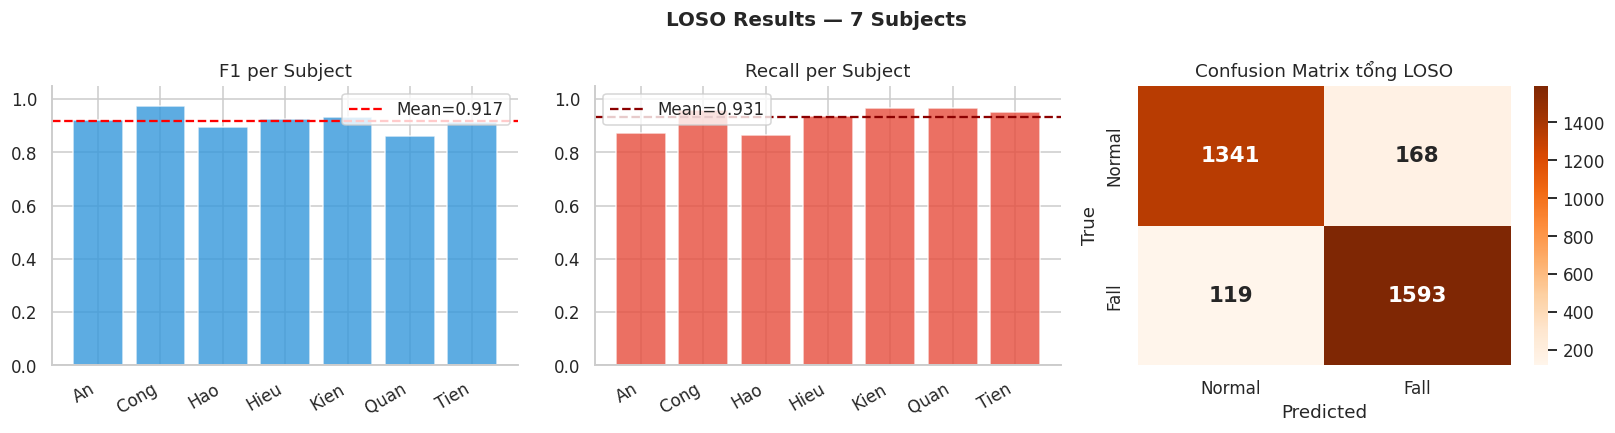

In [ ]:
# ============================================================
# CELL 11: TỔNG KẾT LOSO
# ============================================================
# In bảng kết quả từng subject và confusion matrix tổng hợp.
# Subject nào có F1 thấp → cần thu thêm data hoặc kiểm tra chất lượng data.

n_folds = len(loso_results['test_subject'])

print('═' * 76) # Tăng độ dài đường kẻ cho vừa bảng mới
print(f'   KẾT QUẢ LOSO — CNN + LSTM + MHA ({n_folds} Folds)')
print('═' * 76)
# 💡 Đã thêm cột Threshold vào bảng in
print(f'{"Subject":<10} {"F1":>7} {"Recall":>8} {"Prec":>7} '
      f'{"AUC-ROC":>9} {"FN(Miss)":>9} {"FP(Alarm)":>10} {"Threshold":>10}')
print('─' * 76)

for i, subj in enumerate(loso_results['test_subject']):
    print(f'{subj:<10} '
          f'{loso_results["f1"][i]:>7.4f} '
          f'{loso_results["recall"][i]:>8.4f} '
          f'{loso_results["precision"][i]:>7.4f} '
          f'{loso_results["auc_roc"][i]:>9.4f} '
          f'{loso_results["fn"][i]:>9} '
          f'{loso_results["fp"][i]:>10} '
          f'{loso_results["threshold"][i]:>10.3f}') # Cột Threshold

print('─' * 76)
print(f'{"Mean":<10} '
      f'{np.mean(loso_results["f1"]):>7.4f} '
      f'{np.mean(loso_results["recall"]):>8.4f} '
      f'{np.mean(loso_results["precision"]):>7.4f} '
      f'{np.mean(loso_results["auc_roc"]):>9.4f} '
      f'{"":>9} {"":>10} '
      f'{np.mean(loso_results["threshold"]):>10.3f}') # Mean Threshold

print(f'{"Std":<10} '
      f'{np.std(loso_results["f1"]):>7.4f} '
      f'{np.std(loso_results["recall"]):>8.4f} '
      f'{np.std(loso_results["precision"]):>7.4f} '
      f'{np.std(loso_results["auc_roc"]):>9.4f} '
      f'{"":>9} {"":>10} '
      f'{np.std(loso_results["threshold"]):>10.3f}') # Std Threshold
print('═' * 76)

total_tn = sum(loso_results['tn'])
total_fp = sum(loso_results['fp'])
total_fn = sum(loso_results['fn'])
total_tp = sum(loso_results['tp'])

print(f'\nTổng confusion matrix (LOSO):')
print(f'  TN={total_tn} | FP={total_fp} ← False Alarm (báo nhầm)')
print(f'  FN={total_fn} ← Miss ⚠️ (bỏ sót ngã) | TP={total_tp}')
print(f'  False Alarm Rate   : {total_fp/max(total_fp+total_tn,1):.2%}')
print(f'  Miss Detection Rate: {total_fn/max(total_fn+total_tp,1):.2%}')

# ============================================================
# Phần Visualization bên dưới giữ nguyên 100% của bạn
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'LOSO Results — {n_folds} Subjects', fontsize=13, fontweight='bold')

subjs = loso_results['test_subject']
x_pos = np.arange(n_folds)

axes[0].bar(x_pos, loso_results['f1'], color='#3498db', alpha=0.8)
axes[0].axhline(np.mean(loso_results['f1']), color='red', ls='--',
                label=f'Mean={np.mean(loso_results["f1"]):.3f}')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(subjs, rotation=30 if n_folds > 6 else 0, ha='right')
axes[0].set_title('F1 per Subject'); axes[0].set_ylim(0, 1.05)
axes[0].legend(); sns.despine(ax=axes[0])

axes[1].bar(x_pos, loso_results['recall'], color='#e74c3c', alpha=0.8)
axes[1].axhline(np.mean(loso_results['recall']), color='darkred', ls='--',
                label=f'Mean={np.mean(loso_results["recall"]):.3f}')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(subjs, rotation=30 if n_folds > 6 else 0, ha='right')
axes[1].set_title('Recall per Subject'); axes[1].set_ylim(0, 1.05)
axes[1].legend(); sns.despine(ax=axes[1])

cm_total = np.array([[total_tn, total_fp], [total_fn, total_tp]])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size':14,'weight':'bold'}, ax=axes[2])
axes[2].set_title('Confusion Matrix tổng LOSO')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'results_loso_v3.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# CELL 12: MODEL CUỐI CÙNG ĐỂ DEPLOY (Toàn bộ 7 Subjects)
# ============================================================
import json
import os
from collections import Counter
import gc

print('═' * 60)
print('  HUẤN LUYỆN MÔ HÌNH CUỐI CÙNG CHO PHẦN CỨNG')
print('═' * 60)

# 1. TRÍCH XUẤT SIÊU THAM SỐ XUẤT SẮC NHẤT
# Lấy bộ thông số xuất hiện nhiều nhất qua các Fold LOSO (tính chất majority vote)
def get_best_dl_params(params_list):
    params_str = [json.dumps(p, sort_keys=True) for p in params_list]
    best_str = Counter(params_str).most_common(1)[0][0]
    return json.loads(best_str)

best_deploy_hp = get_best_dl_params(loso_results['best_params'])
print(f'🚀 Tham số chốt để Deploy: {best_deploy_hp}')

# 2. CHUẨN HÓA TRÊN TOÀN BỘ DỮ LIỆU
# Lần này ta không chia Test nữa, tận dụng 100% dữ liệu để model thông minh nhất có thể.
scaler_final = StandardScaler()
X_all_s = scaler_final.fit_transform(X_raw.reshape(-1, NUM_CHANNELS)).reshape(-1, WINDOW_SIZE, NUM_CHANNELS).astype(np.float32)

cw_deploy = compute_class_weight('balanced', classes=np.array([0,1]), y=y_raw)
cw_dep_dict = {0: float(cw_deploy[0]), 1: float(cw_deploy[1])}

# 3. BUILD VÀ TRAIN MÔ HÌNH TRIỂN KHAI
tf.keras.backend.clear_session()
gc.collect()

final_model = build_model(
    input_shape=(WINDOW_SIZE, NUM_CHANNELS),
    lstm_units=best_deploy_hp['lstm_units'],
    drop_rate=best_deploy_hp['drop_rate'],
    l2_reg=best_deploy_hp['l2_reg']
)

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_deploy_hp['lr'], clipnorm=1.0),
    loss=focal_loss_fn, metrics=['accuracy']
)

def deploy_lr_schedule(epoch, lr):
    warmup = 10
    if epoch < warmup: return float(best_deploy_hp['lr'] * (epoch + 1) / warmup)
    progress = (epoch - warmup) / max(EPOCHS - warmup, 1)
    return float(best_deploy_hp['lr'] * 0.5 * (1 + np.cos(np.pi * progress)))

print('⚙️ Đang huấn luyện (có thể mất vài phút)...')
final_model.fit(
    X_all_s, y_raw, epochs=60, batch_size=BATCH_SIZE,
    class_weight=cw_dep_dict, verbose=1,
    callbacks=[keras.callbacks.LearningRateScheduler(deploy_lr_schedule, verbose=0)]
)

# 4. TÌM THRESHOLD THỰC TẾ TRÊN TOÀN BỘ DỮ LIỆU ĐÃ HỌC
def optimal_threshold(y_true, y_proba):
    prec, rec, thrs = precision_recall_curve(y_true, y_proba)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    best_idx = np.argmax(f1[:-1])
    return float(thrs[best_idx]) if len(thrs) > 0 else 0.5

final_proba = final_model.predict(X_all_s, verbose=0).flatten()
deploy_thr  = optimal_threshold(y_raw, final_proba)
print(f'\n🎯 Ngưỡng cắt (Threshold) nhúng vào thiết bị: {deploy_thr:.4f}')

# 5. XUẤT ARTIFACTS (KERAS, TFLITE, JSON, SCALER)
ckpt_final    = OUTPUT_DIR / 'fall_detection_v3_final.keras'
path_scaler_f = OUTPUT_DIR / 'scaler_v3_final.pkl'
path_config_f = OUTPUT_DIR / 'config_v3_final.json'
path_tflite_f = OUTPUT_DIR / 'fall_detection_v3_final.tflite'

final_model.save(ckpt_final)
with open(path_scaler_f, 'wb') as f:
    pickle.dump(scaler_final, f)
print(f'✅ Đã lưu Keras Model & Scaler')

# Tạo Config JSON cho bộ phận nhúng/Frontend
n_subjects = len(sorted(set(persons_raw)))
cfg_final = {
    'version'         : 'v3_final_tuned',
    'architecture'    : 'CNN + LSTM + MHA',
    'train_mode'      : 'all_subjects_deploy',
    'hyperparameters' : best_deploy_hp,
    'deployment_threshold': deploy_thr,
    'n_hot_windows'   : N_HOT_WINDOWS,
    'sample_rate'     : SAMPLE_RATE,
    'window_size'     : WINDOW_SIZE,
    'loso_summary': {
        'mean_f1'     : round(float(np.mean(loso_results['f1'])),    4),
        'mean_recall' : round(float(np.mean(loso_results['recall'])),4),
        'mean_auc_roc': round(float(np.mean(loso_results['auc_roc'])),4),
    }
}
with open(path_config_f, 'w') as f:
    json.dump(cfg_final, f, indent=2)

# Convert sang TensorFlow Lite (Dành riêng cho ESP32-C3 / Mobile)
try:
    conv = tf.lite.TFLiteConverter.from_keras_model(final_model)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    conv.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS,
        tf.lite.OpsSet.SELECT_TF_OPS # Cần thiết vì ta xài Layer Norm trong MHA
    ]
    conv._experimental_lower_tensor_list_ops = False

    tflite_bytes = conv.convert()
    with open(path_tflite_f, 'wb') as f:
        f.write(tflite_bytes)

    print(f'✅ TFLite sinh thành công: {path_tflite_f.name} ({(os.path.getsize(path_tflite_f) / 1024):.1f} KB)')
except Exception as e:
    print(f'⚠️ Lỗi Convert TFLite (thường do ops không support trên MCU): {e}')

print('\n🎉 Hoàn tất toàn bộ chu trình AI Training Pipeline!')

════════════════════════════════════════════════════════════
  HUẤN LUYỆN MÔ HÌNH CUỐI CÙNG CHO PHẦN CỨNG
════════════════════════════════════════════════════════════
🚀 Tham số chốt để Deploy: {'drop_rate': 0.4, 'l2_reg': 0.0002, 'lr': 0.0005, 'lstm_units': 64}
⚙️ Đang huấn luyện (có thể mất vài phút)...
Epoch 1/60
101/101 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - accuracy: 0.6004 - loss: 0.2276 - learning_rate: 5.0000e-05
Epoch 2/60
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.7044 - loss: 0.1639 - learning_rate: 1.0000e-04
Epoch 3/60
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.7625 - loss: 0.1351 - learning_rate: 1.5000e-04
Epoch 4/60
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - accuracy: 0.8184 - loss: 0.1196 - learning_rate: 2.0000e-04
Epoch 5/60
101/101 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.8504 - loss: 0.1097 - learning_rate: 2.5000e-04
Epoch 6/60
101/101 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.8736 - loss: 0.1024 - learning_rate: 3.0